In [ ]:
!pip3 install torch torchvision astroquery lightkurve pandas numpy matplotlib

In [2]:
import matplotlib.pyplot as plt
from astroquery.mast import Observations
from astropy.io import fits
import numpy as np
import lightkurve as lk
from astropy.coordinates import SkyCoord
import astropy.units as u

/opt/anaconda3/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
def visualize_kepler_lightcurve(target_name):
    print(f"Resolving coordinates for {target_name}...")
    
    obs_table = Observations.query_object(target_name, radius="0.01 deg")
    
    kepler_rows = obs_table[
        (obs_table['obs_collection'] == 'Kepler') & 
        (obs_table['obs_id'] != "")
    ]
    
    if len(kepler_rows) == 0:
        print(f"No valid Kepler observations found for {target_name}.")
        print("Available collections at this location:", np.unique(obs_table['obs_collection']))
        return

    print(f"Found {len(kepler_rows)} Kepler data entries. Retrieving products...")
    
    data_products = Observations.get_product_list(kepler_rows[0])
    
    lc_files = Observations.filter_products(data_products, 
                                            productSubGroupDescription='LLC', 
                                            extension='fits')
    
    if len(lc_files) == 0:
        print("No FITS light curves found for this specific observation.")
        return

    print("Downloading FITS file...")
    manifest = Observations.download_products(lc_files[0], mrp_only=False)
    file_path = manifest['Local Path'][0]
    
    with fits.open(file_path) as hdul:
        data = hdul[1].data
        time = data['TIME'].copy()
        flux = data['PDCSAP_FLUX'].copy()
        
    mask = np.isfinite(time) & np.isfinite(flux)
    time, flux = time[mask], flux[mask]
    
    plt.figure(figsize=(10, 5))
    plt.plot(time, flux, 'k.', markersize=0.5)
    plt.title(f"Kepler Light Curve: {target_name}")
    plt.xlabel("Time (BKJD)")
    plt.ylabel("Flux (e-/s)")
    plt.show()


In [4]:
"""search_result = lk.search_lightcurve('Kepler-10', author='Kepler', quarter=3)
lc = search_result.download()

flat_lc = lc.flatten(window_length=401)
folded_lc = flat_lc.fold(period=0.83749)

folded_lc.scatter()
plt.title("Kepler-10b Folded Transit")"""

'search_result = lk.search_lightcurve(\'Kepler-10\', author=\'Kepler\', quarter=3)\nlc = search_result.download()\n\nflat_lc = lc.flatten(window_length=401)\nfolded_lc = flat_lc.fold(period=0.83749)\n\nfolded_lc.scatter()\nplt.title("Kepler-10b Folded Transit")'

In [5]:
def visualize_by_coords(ra, dec, radius="0.05 deg"):
    print(f"Searching coordinates: RA {ra}, Dec {dec}...")
    
    coord = SkyCoord(ra=ra, dec=dec, unit=(u.deg, u.deg), frame='icrs')
    obs_table = Observations.query_region(coord, radius=radius)
    
    mask = (obs_table['obs_collection'] == 'Kepler') & (obs_table['obs_id'] != "")
    kepler_obs = obs_table[mask]
    
    if len(kepler_obs) == 0:
        print("No Kepler data found at these coordinates.")
        return

    target_id = kepler_obs[0]['target_name']
    print(f"Found target: {target_id}. Fetching data products...")

    data_products = Observations.get_product_list(kepler_obs[0]['obsid'])
    
    lc_files = Observations.filter_products(data_products, 
                                            productSubGroupDescription='LLC', 
                                            extension='fits')
    
    if len(lc_files) == 0:
        print(f"No FITS light curves found for {target_id}.")
        return

    print(f"Downloading FITS file for {target_id}...")
    manifest = Observations.download_products(lc_files[0], mrp_only=False)
    file_path = manifest['Local Path'][0]
    
    with fits.open(file_path) as hdul:
        data = hdul[1].data
        time = np.array(data['TIME'], dtype=float)
        flux = np.array(data['PDCSAP_FLUX'], dtype=float)
        
    clean_mask = np.isfinite(time) & np.isfinite(flux)
    time, flux = time[clean_mask], flux[clean_mask]
    
    plt.figure(figsize=(10, 5))
    plt.plot(time, flux, 'k.', markersize=1)
    plt.title(f"Kepler Light Curve | Target: {target_id}")
    plt.xlabel("Time (BKJD)")
    plt.ylabel("Flux ($e^-/s$)")
    plt.grid(True, alpha=0.3)
    plt.show()

# Test with coordinates for Kepler-10 (RA 290.32, Dec 50.25)
# visualize_by_coords(290.322, 50.252)

Resolving coordinates for Kepler-11...
Found 2 Kepler data entries. Retrieving products...
INFO: Found cached file ./mastDownload/Kepler/kplr006541920_lc_Q011111111111111111/kplr006541920-2009166043257_llc.fits with expected size 192960. [astroquery.query]


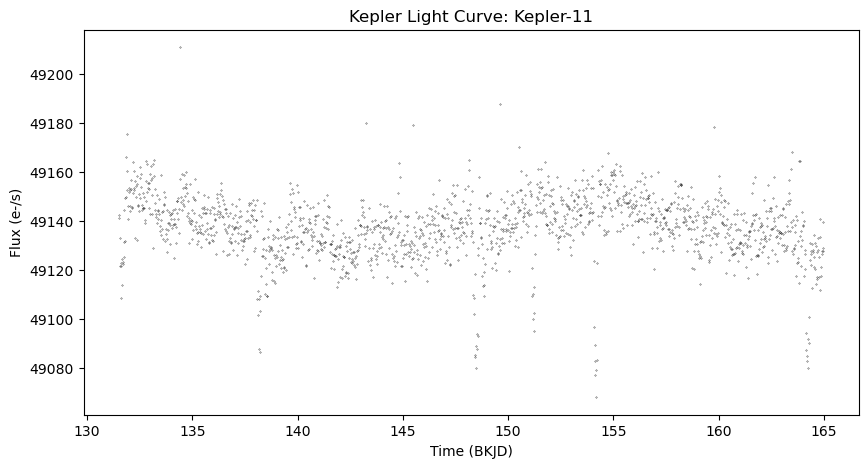

In [6]:
visualize_kepler_lightcurve("Kepler-11")

Searching coordinates: RA 290.322, Dec 50.252...
Found target: kplr011911870. Fetching data products...
INFO: Found cached file ./mastDownload/Kepler/kplr011911870_lc_Q000011111111111111/kplr011911870-2010078095331_llc.fits with expected size 469440. [astroquery.query]


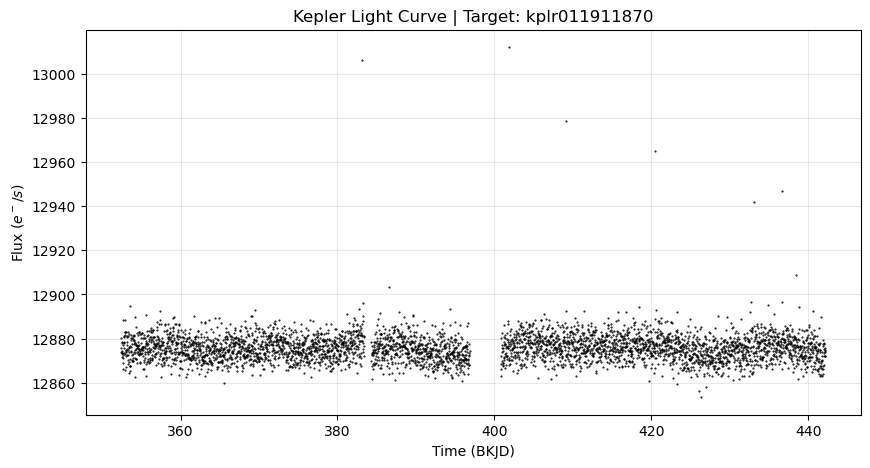

In [7]:
visualize_by_coords(290.322, 50.252)